In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Here we will be doing all the analyiss of the dataset and the model's performance and selecting the best model from each binary classifier and severity classifier


In [2]:
### Analyzing the dataset 

data = pd.read_csv('../Datasets/pre-processedData.csv')

data.head(5)




,Unnamed: 0,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTO,flag_RSTR,flag_S1,flag_S3,flag_SF,flag_SH,is_malicious,Severity_Score,bytes_ratio,total_bytes
0,0,0.0,6.198479,0.000000,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0,1,0,0,0,6.198479,6.198479
1,1,0.0,4.990433,0.000000,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0,1,0,0,0,4.990433,4.990433
2,2,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.0,...,0,0,0,0,0,0,1,2,0.000000,0.000000
3,3,0.0,5.451038,9.006264,0.0,0.0,0.0,0.0,1,0.0,...,0,0,0,0,1,0,0,0,0.544763,14.457302
4,4,0.0,5.298317,6.042633,0.0,0.0,0.0,0.0,1,0.0,...,0,0,0,0,1,0,0,0,0.752321,11.340950


---
### Total Normal vs Attacked Data count


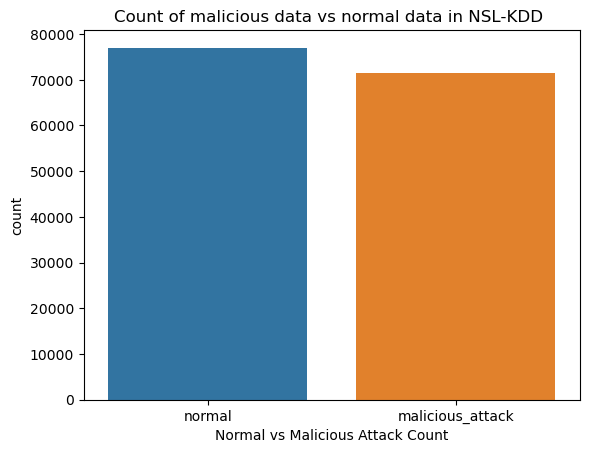

In [3]:
malicious_data_count = data['is_malicious'].map({0:'normal', 1:'malicious_attack'}).value_counts().reset_index()

sns.barplot(data = malicious_data_count, x = 'is_malicious', y = 'count',hue = 'is_malicious' )
plt.xlabel("Normal vs Malicious Attack Count")
plt.title("Count of malicious data vs normal data in NSL-KDD ")
plt.savefig('../Model Pictures/attackvsnormal.png')
plt.show()

### The attack types has been classified into normal and malicious. Malicious Attacks are further divided into three different types: 1. Low Severity, 2. Medium Severity, 3. High Severity 




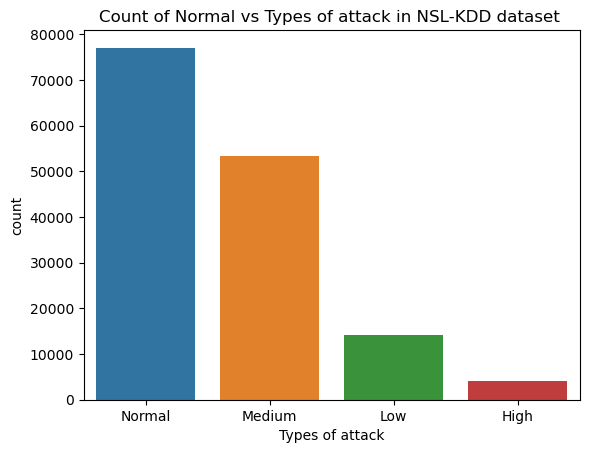

In [4]:
attack_data = pd.read_csv('../Datasets/final_dataset.csv')

severity_mapping = {
    # Level 0: Normal traffic
    'normal': 'Normal',
    
    # Level 1: LOW SEVERITY - Reconnaissance
    'ipsweep': 'Low',       # Network mapping
    'nmap': 'Low',          # Port scanning
    'portsweep': 'Low',     # Port scanning
    'satan': 'Low',         # Security scanner
    'mscan': 'Low',         # Mass scanner
    'saint': 'Low',         # Security scanner
    
    # Level 2: MEDIUM SEVERITY - Availability attacks
    'back': 'Medium',       # DoS
    'land': 'Medium',       # DoS
    'neptune': 'Medium',    # SYN flood
    'pod': 'Medium',        # Ping of death
    'smurf': 'Medium',      # ICMP flood
    'teardrop': 'Medium',   # DoS
    'apache2': 'Medium',    # DoS
    'udpstorm': 'Medium',   # DoS
    'processtable': 'Medium', # DoS
    'worm': 'Medium',      # Self-propagating
    'mailbomb': 'Medium',   # Email-based DoS
    # Level 3: HIGH SEVERITY - Unauthorized access
    'guess_passwd': 'High',     # Brute force
    'ftp_write': 'High',        # File upload
    'imap': 'High',             # Mail access
    'phf': 'High',              # CGI exploit
    'multihop': 'High',         # Multi-stage
    'warezmaster': 'High',      # Illegal software
    'warezclient': 'High',      # Illegal software client
    'spy': 'High',              # Spyware
    'xlock': 'High',            # Lockout attack
    'xsnoop': 'High',           # Snooping
    'snmpguess': 'High',        # SNMP brute force
    'snmpgetattack': 'High',    # SNMP exploit
    'httptunnel': 'High',       # Tunneling
    'sendmail': 'High',         # Mail exploit
    'named': 'High',            # DNS exploit
    'buffer_overflow': 'High',  # Memory corruption
    'loadmodule': 'High',       # Kernel module
    'perl': 'High',             # Script execution
    'rootkit': 'High',          # Rootkit
    'sqlattack': 'High',        # SQL injection
    'xterm': 'High',            # Remote terminal
    'ps': 'High'                # Process attack
}

types_of_attack = attack_data['attack'].map(severity_mapping)
attack_count = types_of_attack.value_counts().reset_index()


sns.barplot(x = 'attack', y = 'count', data = attack_count, hue = 'attack')
plt.xlabel("Types of attack")
plt.title("Count of Normal vs Types of attack in NSL-KDD dataset ")
plt.savefig('../Model Pictures/attackdistribution.png')
plt.show()

---
### Model's performance on analyzing the binary classification !

In [5]:
## Binary classification model's performance data 

data = pd.read_csv('../Datasets/models_performance.csv')
data.head(6)
data.drop(columns=['Unnamed: 0'], inplace = True)

data['precision'] = data['precision']* 100
data['recall'] = data['recall']* 100
data['f1_score'] = data['f1_score']* 100
data['false_alarm'] = data['false_alarm'] * 100
data['missed_attack_rate'] = data['missed_attack_rate'] * 100
data['roc_score'] = data['roc_score'] * 100
data.head(5)

,models,precision,recall,f1_score,false_alarm,missed_attack_rate,roc_score
0,LR,95.969014,98.211028,97.077078,3.805825,1.788972,99.311959
1,SVM,95.916423,98.870492,97.371057,3.883495,1.129508,97.493499
2,GaussianNB,90.100694,92.907254,91.482454,9.417476,7.092746,95.545168
3,DecisionTrees,98.298200,98.470605,98.384327,1.572816,1.529395,98.448895
4,RandomTrees,98.915914,99.859689,99.385561,1.009709,0.140311,99.424990


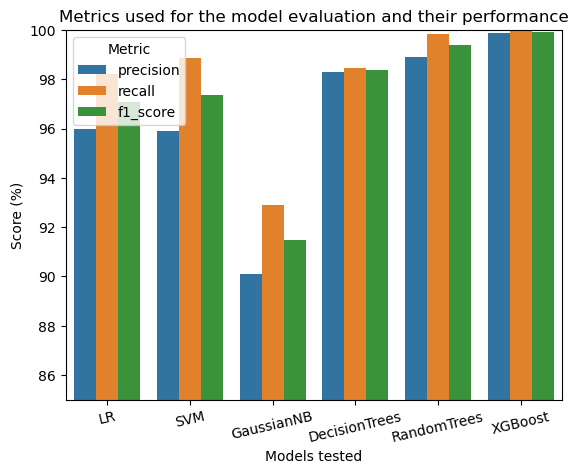

In [6]:
### Precision score 
data_long = data.melt(
    id_vars='models',
    value_vars=['precision', 'recall', 'f1_score'],
    var_name='metric',
    value_name='score'
)

sns.barplot(
    x='models',
    y='score',
    hue='metric',
    data=data_long
)

plt.ylim(85, 100)
plt.xticks(rotation=13)
plt.xlabel("Models tested")
plt.ylabel('Score (%)')
plt.title("Metrics used for the model evaluation and their performance")
plt.legend(title='Metric')
plt.savefig('../Model Pictures/metricsforbinary.png')
plt.show()

---
### False Positive Rate and False Negative Rate 

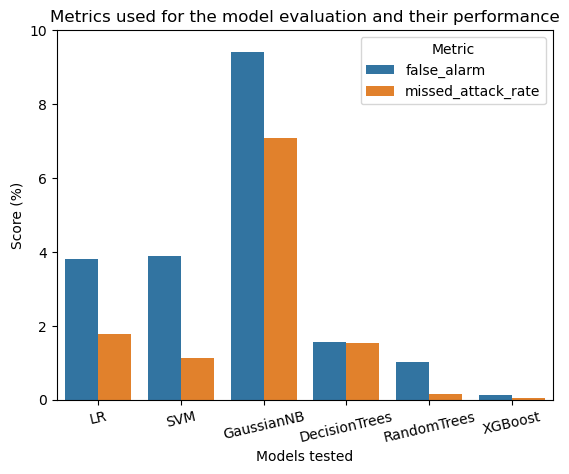

In [7]:
fpr_fnr = data.melt(id_vars = 'models', value_vars = ['false_alarm', 'missed_attack_rate'], var_name = 'metric', value_name= 'score')

sns.barplot(x = 'models', y = 'score', data = fpr_fnr, hue = 'metric')
plt.ylim(0, 10)
plt.xticks(rotation=13)
plt.xlabel("Models tested")
plt.ylabel('Score (%)')
plt.title("Metrics used for the model evaluation and their performance")
plt.legend(title='Metric')
plt.savefig('../Model Pictures/fnr_fpr.png')
plt.show()

---
### Evaluation of the severity classifier model 

In [8]:
severity_data = pd.read_csv('../Datasets/severity_performance.csv')
severity_data.drop(columns='Unnamed: 0', inplace=True)
columns = severity_data.select_dtypes(['int','float'])

for i in columns:
    severity_data[i] = severity_data[i] * 100
severity_data.head(5)

,model_name,model_mae,model_cohen,precision_rare_attacks,recall_rare_attacks,f1_rare_attacks,Misclassified_attacks,false_alarm
0,LR,0.741622,98.626562,97.569866,99.013564,98.286414,0.148346,0.986436
1,SVM,0.706640,98.662961,98.873592,97.410604,98.136646,0.066756,2.589396
2,GaussianNB,7.535157,84.578514,86.561743,88.162762,87.354918,0.823320,11.837238
3,DecisionTrees,1.525222,97.189572,95.094340,93.218249,94.146949,0.289275,6.781751
4,RandomForest,0.699643,98.892238,99.613402,95.314427,97.416509,0.022252,4.685573


---
### Mean Absolute Error (MAE) and Cohen Kappa Score of the severity model

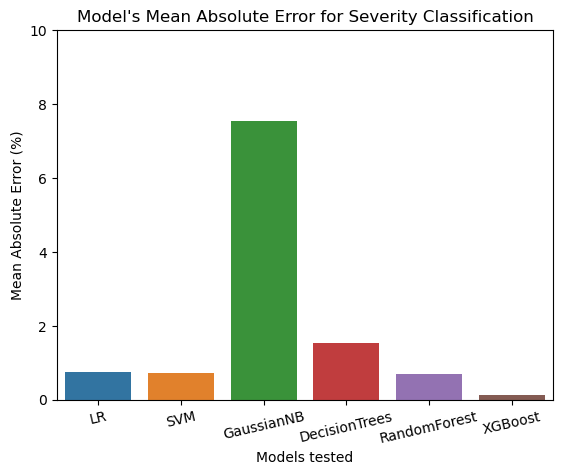

In [9]:
## Mean absolute error of the model 

sns.barplot(x = 'model_name', y = 'model_mae', hue = 'model_name' ,data = severity_data)
plt.xlabel('Models tested')
plt.ylabel('Mean Absolute Error (%)')
plt.ylim(0,10)
plt.title("Model's Mean Absolute Error for Severity Classification")
plt.savefig('../Model Pictures/mae.png')
plt.xticks(rotation = 13)
plt.show()

### Cohen Kappa score for the severity modoel

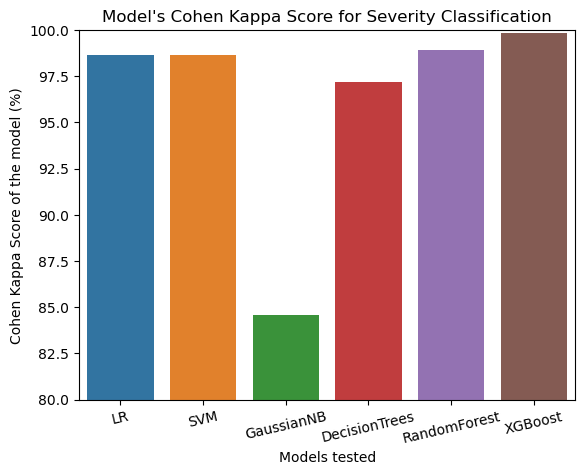

In [10]:
sns.barplot(x = 'model_name', y = 'model_cohen', hue = 'model_name' ,data = severity_data)
plt.xlabel('Models tested')
plt.ylabel('Cohen Kappa Score of the model (%)')
plt.ylim(80,100)
plt.title("Model's Cohen Kappa Score for Severity Classification")
plt.savefig('../Model Pictures/mae.png')
plt.xticks(rotation = 13)
plt.show()

### Model's precision, recall, and f1 score for the severity classifier for the rare attacks


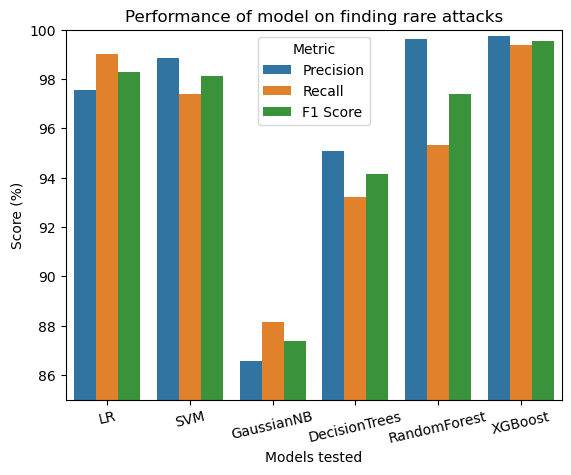

In [12]:
metric_map = {
    'precision_rare_attacks': 'Precision',
    'recall_rare_attacks': 'Recall',
    'f1_rare_attacks': 'F1 Score'
}
rare_metrics = severity_data.melt(
    id_vars='model_name',
    value_vars=list(metric_map.keys()),
    var_name='metric',
    value_name='score'
)
rare_metrics['metric'] = rare_metrics['metric'].map(metric_map)
sns.barplot(
    x='model_name',
    y='score',
    hue='metric',
    data=rare_metrics
)

plt.ylim(85, 100)
plt.xticks(rotation=13)
plt.xlabel("Models tested")
plt.ylabel('Score (%)')
plt.title("Performance of model on finding rare attacks")
plt.legend(title='Metric')
plt.savefig('../Model Pictures/raremodelevaluation.png')
plt.show()

---
### Misclassification error rate and False Alarm Rate of the models

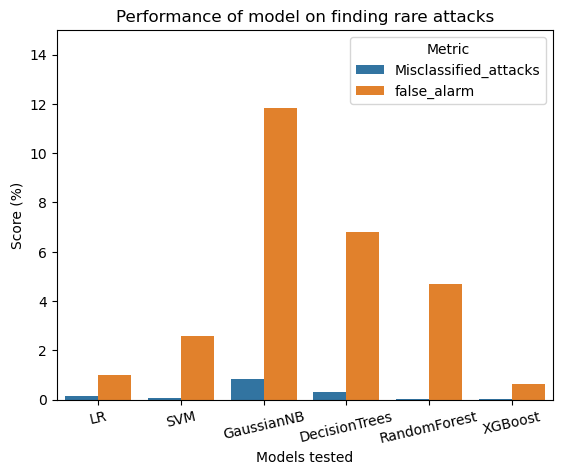

In [24]:
### False Alarm rate and misclassification error rate of the models! 
fpr_fnr = severity_data.melt(id_vars = 'model_name', value_vars = ['Misclassified_attacks', 'false_alarm'], var_name = 'metric', value_name= 'score')
sns.barplot(
    x='model_name',
    y='score',
    hue='metric',
    data=fpr_fnr
)

plt.ylim(0,15)
plt.xticks(rotation=13)
plt.xlabel("Models tested")
plt.ylabel('Score (%)')
plt.title("Performance of model on finding rare attacks")
plt.legend(title='Metric')
plt.savefig('../Model Pictures/fpr_fnr_rare_severity.png')
plt.show()